In [31]:
import numpy as np
import matplotlib.pyplot as plt

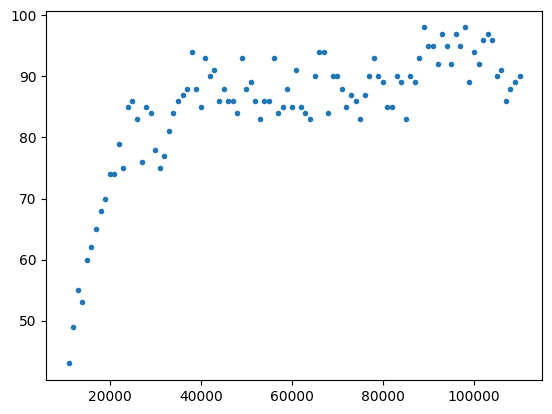

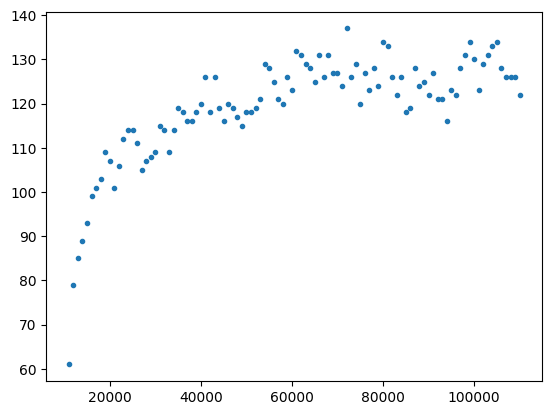

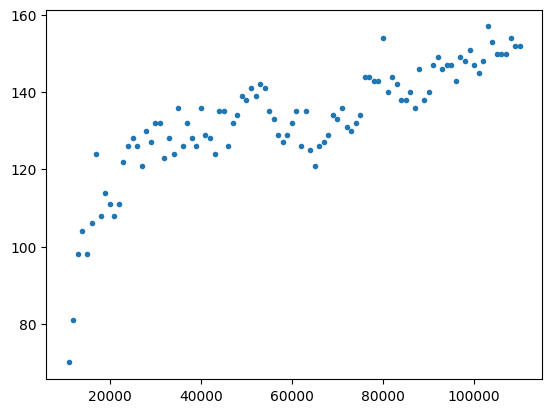

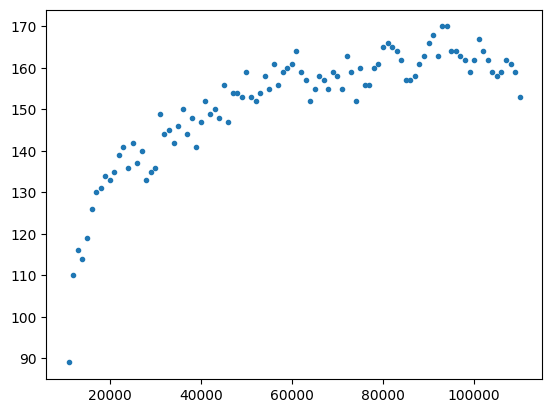

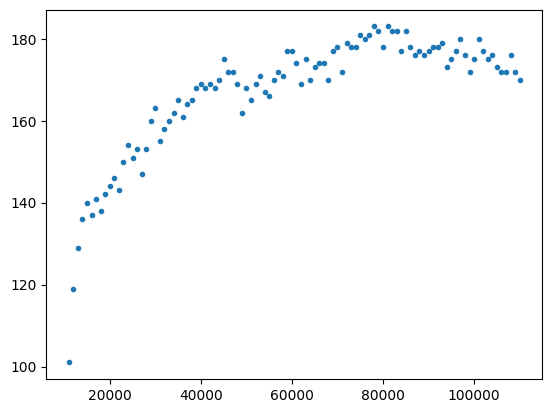

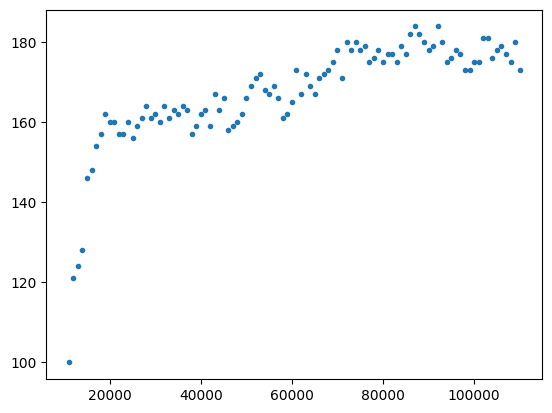

In [32]:
files = ['./logs_298K/log_01p.lammps', './logs_298K/log_05p.lammps', './logs_298K/log_1p.lammps', './logs_298K/log_2p.lammps', './logs_298K/log_5p.lammps', './logs_298K/log_10p.lammps']
N_CO2_298 = []
P = [0.1, 0.5, 1, 2, 5, 10]

for file in files:
    data = np.genfromtxt(file, skip_header=328, max_rows=100)
    steps = data[:, 0]
    num_of_co2 = data[:, 3]
    plt.figure()
    plt.plot(steps, num_of_co2, '.')
    plt.show()

    N_CO2_298.append(np.mean(num_of_co2[80:]))

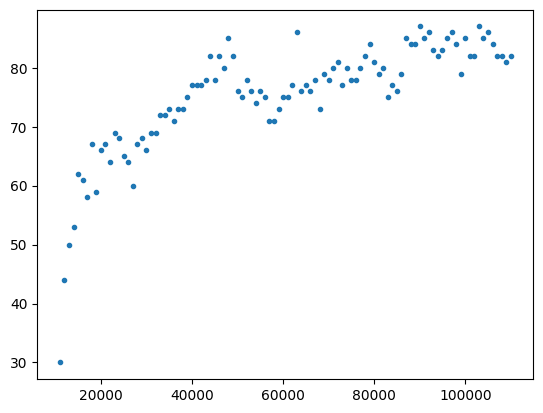

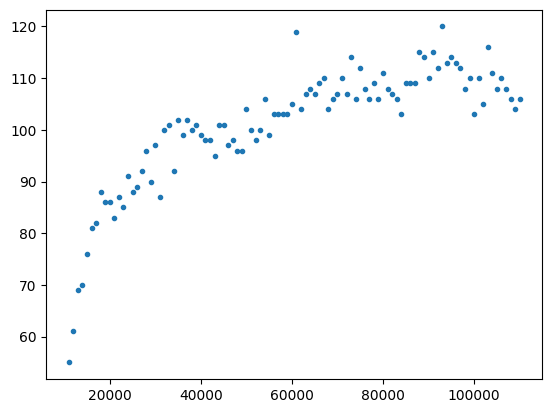

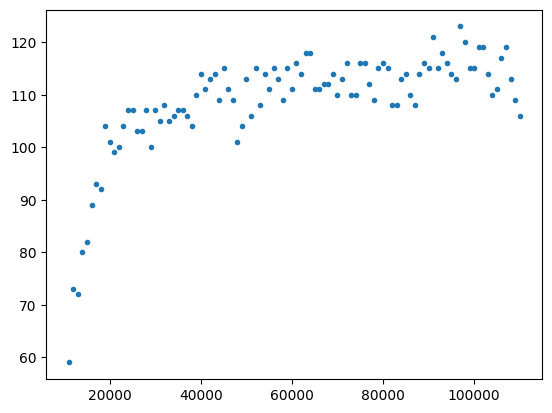

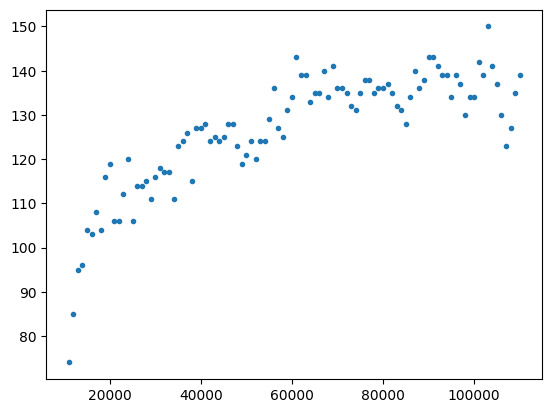

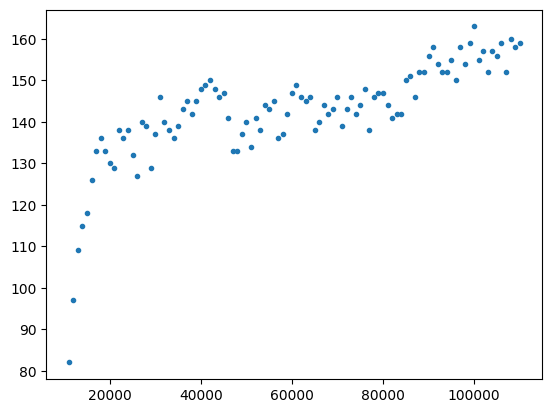

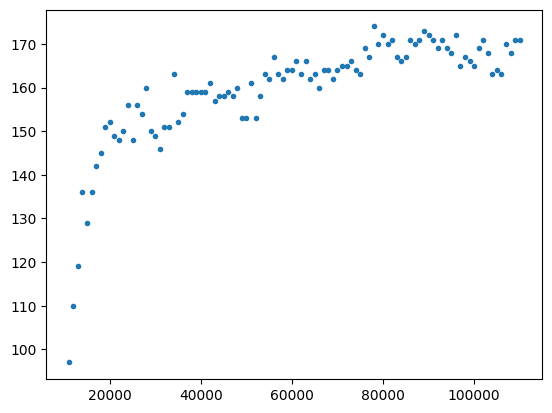

In [33]:
files = ['./logs_323K/log_01p.lammps', './logs_323K/log_05p.lammps', './logs_323K/log_1p.lammps', './logs_323K/log_2p.lammps', './logs_323K/log_5p.lammps', './logs_323K/log_10p.lammps']
N_CO2_323 = []
P = [0.1, 0.5, 1, 2, 5, 10]

for file in files:
    data = np.genfromtxt(file, skip_header=328, max_rows=100)
    steps = data[:, 0]
    num_of_co2 = data[:, 3]
    plt.figure()
    plt.plot(steps, num_of_co2, '.')
    plt.show()

    N_CO2_323.append(np.mean(num_of_co2[80:]))

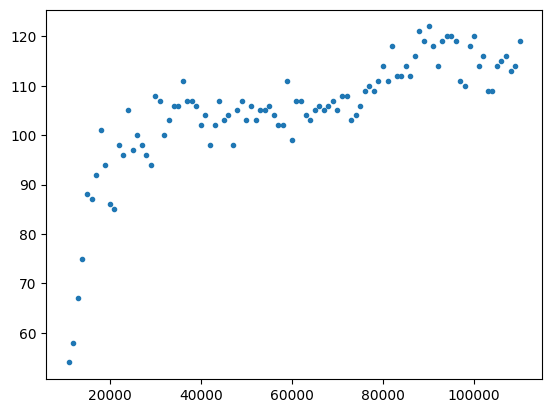

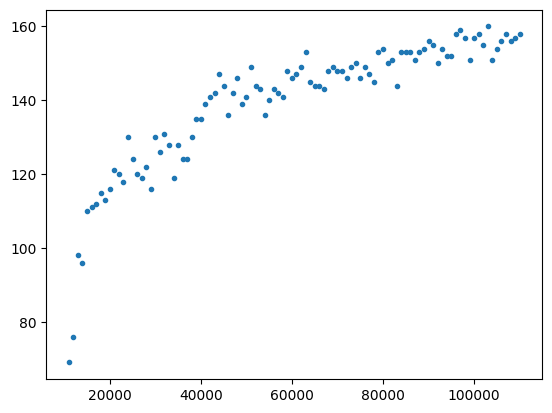

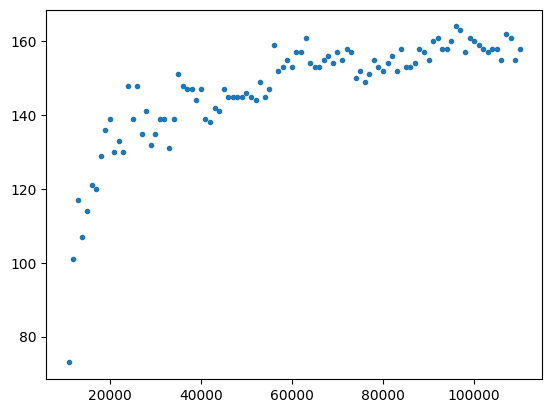

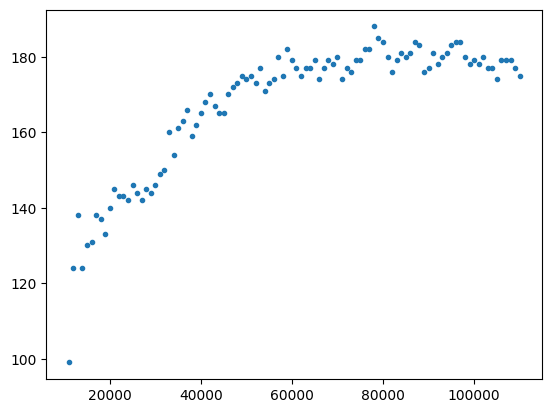

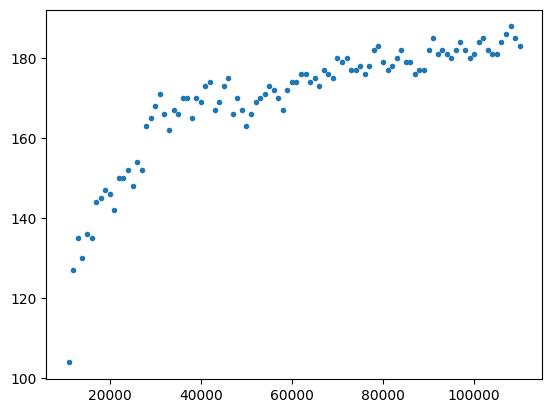

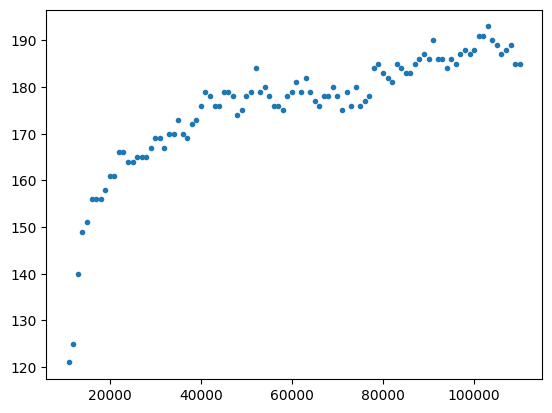

In [58]:
files = ['./logs_273K/log_0.1p.lammps', './logs_273K/log_0.5p.lammps', './logs_273K/log_1.0p.lammps', './logs_273K/log_2.0p.lammps', './logs_273K/log_5.0p.lammps', './logs_273K/log_10.0p.lammps']
N_CO2_273 = []
P = [0.1, 0.5, 1, 2, 5, 10]

for file in files:
    data = np.genfromtxt(file, skip_header=328, max_rows=100)
    steps = data[:, 0]
    num_of_co2 = data[:, 3]
    plt.figure()
    plt.plot(steps, num_of_co2, '.')
    plt.show()

    N_CO2_273.append(np.mean(num_of_co2[80:]))

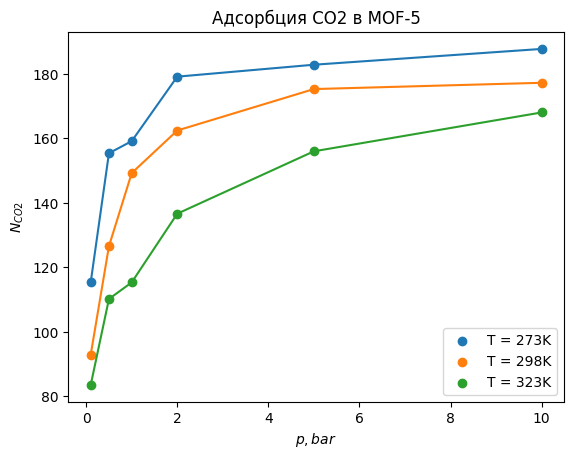

[np.float64(115.4), np.float64(155.4), np.float64(159.15), np.float64(179.15), np.float64(182.85), np.float64(187.75)]
[ 92.95 126.55 149.25 162.45 175.3  177.25]
[ 83.55 110.2  115.35 136.65 156.   168.05]


In [62]:
plt.figure()
plt.plot(P, N_CO2_273)
plt.scatter(P, N_CO2_273, label = 'T = 273K')
plt.plot(P, N_CO2_298)
plt.scatter(P, N_CO2_298, label = 'T = 298K')
plt.plot(P, N_CO2_323)
plt.scatter(P, N_CO2_323, label = 'T = 323K')
plt.xlabel(r'$p, bar$')
plt.ylabel(r'$N_{CO2}$')
plt.title('Адсорбция CO2 в MOF-5')
plt.legend(loc = 'best')
plt.show()

print(N_CO2_273)
print(N_CO2_298)
print(N_CO2_323)

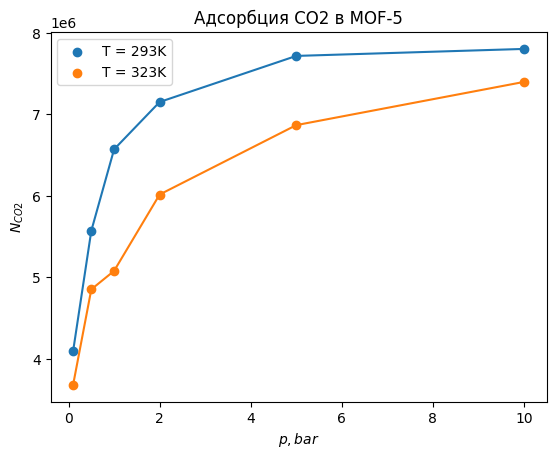

In [42]:
import numpy as np

M_CO2 = 44.01  # г/моль - молярная масса CO2
M_MOF5 = 769.54  # г/моль - молярная масса одной формульной единицы MOF-5
N_A = 6.022e23  # число Авогадро
# mass_CO2 = n_molecules * M_CO2 / N_A * 1e3  # масса CO2 в г
mass_MOF = M_MOF5 / N_A * 1e3  # масса MOF в г

mmol_per_g_298 = []
mmol_per_g_323 = []

# Перевод в ммоль/г
for N in N_CO2_298:
    # mmol_per_g_298.append((N / N_A) * 1000 / mass_MOF)
    mmol_per_g_298.append(N*M_CO2*1e3)
for N in N_CO2_323:
    # mmol_per_g_323.append((N / N_A) * 1000 / mass_MOF)
    mmol_per_g_323.append(N*M_CO2*1e3)

plt.figure()
plt.plot(P, mmol_per_g_298)
plt.scatter(P, mmol_per_g_298, label = 'T = 293K')
plt.plot(P, mmol_per_g_323)
plt.scatter(P, mmol_per_g_323, label = 'T = 323K')
plt.xlabel(r'$p, bar$')
plt.ylabel(r'$N_{CO2}$')
plt.title('Адсорбция CO2 в MOF-5')
plt.legend(loc = 'best')
plt.show()

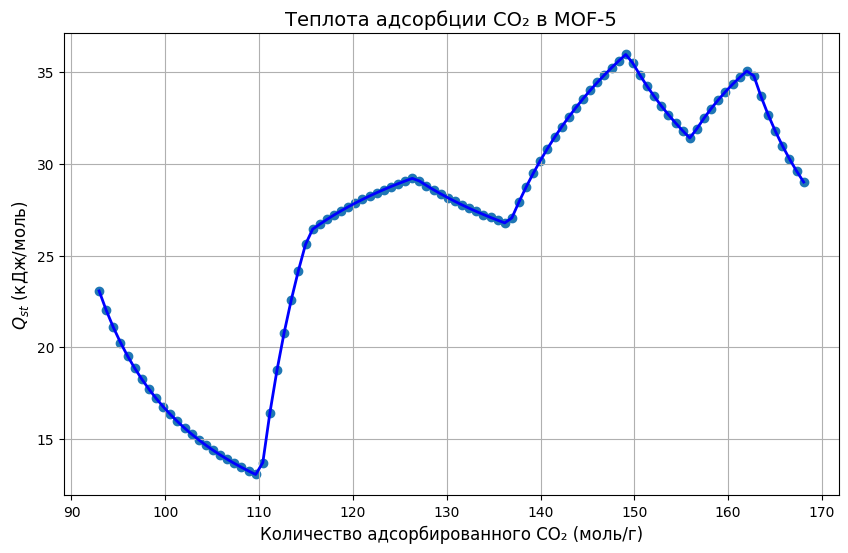

Средняя теплота адсорбции: 26.76 кДж/моль
Теплота адсорбции при малых N: 23.08 кДж/моль


In [40]:
from scipy.interpolate import interp1d

N_CO2_298 = np.array(N_CO2_298)
N_CO2_323 = np.array(N_CO2_323)

# Функции для интерполяции P(N) для каждой температуры
interp_298 = interp1d(N_CO2_298, P, fill_value='extrapolate')  # P = f(N) при T=293K
interp_323 = interp1d(N_CO2_323, P, fill_value='extrapolate')  # P = f(N) при T=323K

# Общие значения N для сравнения (минимум из диапазонов)
N_common = np.linspace(max(N_CO2_323.min(), N_CO2_298.min()), min(N_CO2_323.max(), N_CO2_298.max()), 100)

# Давления для общих N
P_298 = interp_298(N_common)
P_323 = interp_323(N_common)

R = 8.314  # Дж/(моль·К)
T1 = 293   # K
T2 = 323   # K

# Логарифмы давлений
ln_P_T1 = np.log(P_298)
ln_P_T2 = np.log(P_323)

# Расчет Q_st для каждой изостеры (N_common)
Q_st = -R * (ln_P_T2 - ln_P_T1) / (1/T2 - 1/T1)


plt.figure(figsize=(10, 6))
plt.plot(N_common, Q_st / 1000, 'b-', linewidth=2)  # Переводим в кДж/моль
plt.scatter(N_common, Q_st/1000)
plt.xlabel('Количество адсорбированного CO₂ (моль/г)', fontsize=12)
plt.ylabel('$Q_{st}$ (кДж/моль)', fontsize=12)
plt.title('Теплота адсорбции CO₂ в MOF-5', fontsize=14)
plt.grid(True)
plt.show()

Q_st_avg = np.mean(Q_st) / 1000  # Переводим в кДж/моль
print(f"Средняя теплота адсорбции: {Q_st_avg:.2f} кДж/моль")

Q_st_initial = Q_st[0] / 1000  # Первое значение (для минимального заполнения)
print(f"Теплота адсорбции при малых N: {Q_st_initial:.2f} кДж/моль")

Результаты при 273K:
P (bar) | N_CO2 | wt% | mmol/g
----------------------------------------
   0.1 |    84 | 37.4 | 13.57
   0.5 |   110 | 44.1 | 17.90
   1.0 |   115 | 45.2 | 18.74
   2.0 |   137 | 49.4 | 22.20
   5.0 |   156 | 52.7 | 25.34
  10.0 |   168 | 54.6 | 27.30

Параметры модели Ленгмюра:
qmax = 24.59 ± 1.68 ммоль/г
K = 8.325 ± 3.844 бар^-1


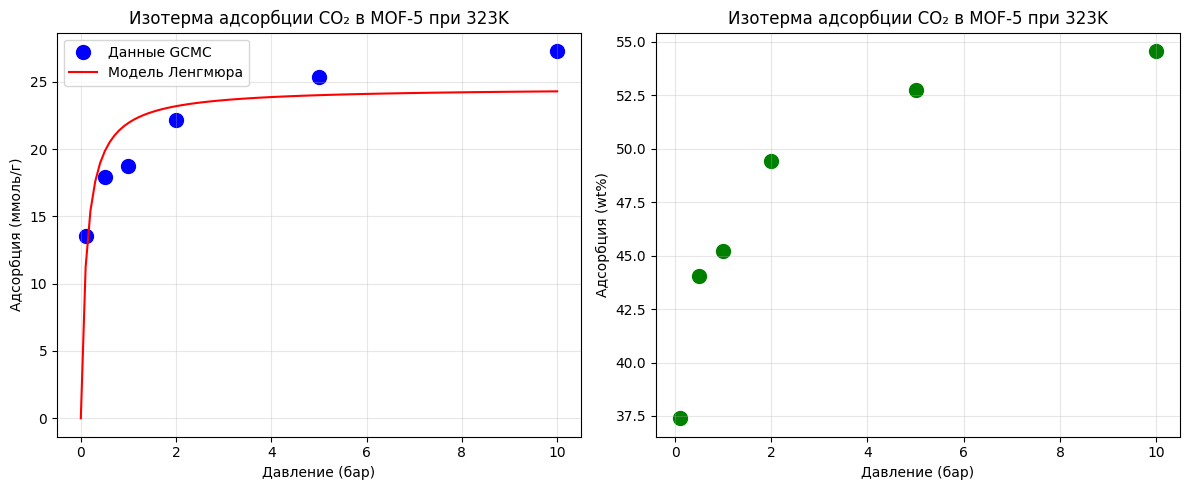

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# Константы
M_CO2 = 44.01  # г/моль - молярная масса CO2
M_MOF5 = 769.54  # г/моль - молярная масса одной формульной единицы MOF-5
N_A = 6.022e23  # число Авогадро

# Для элементарной ячейки MOF-5:
# 8 формульных единиц Zn4O(BDC)3
n_formula_units = 8
M_unit_cell = n_formula_units * M_MOF5  # масса элементарной ячейки в г/моль

def molecules_to_wt_percent(n_molecules):
    """Конвертация количества молекул CO2 в массовые проценты"""
    mass_CO2 = n_molecules * M_CO2 / N_A * 1e3  # масса CO2 в г
    mass_MOF = M_unit_cell / N_A * 1e3  # масса MOF в г
    wt_percent = (mass_CO2 / (mass_MOF + mass_CO2)) * 100
    return wt_percent

def molecules_to_mmol_g(n_molecules):
    """Конвертация в ммоль/г"""
    mol_CO2 = n_molecules / N_A * 1e3  # моль CO2
    mass_MOF = M_unit_cell / N_A * 1e6  # масса MOF в мг
    mmol_per_g = mol_CO2 / mass_MOF * 1e6
    return mmol_per_g

def langmuir_model(P, qmax, K):
    """Модель изотермы Ленгмюра: q = qmax * K*P / (1 + K*P)"""
    return qmax * K * P / (1 + K * P)

def dual_site_langmuir(P, qmax1, K1, qmax2, K2):
    """Двухсайтовая модель Ленгмюра"""
    return qmax1 * K1 * P / (1 + K1 * P) + qmax2 * K2 * P / (1 + K2 * P)

# Чтение ваших данных (замените на реальные данные)
# Формат: давление (бар), количество молекул
data_273K = np.array([
    [0.1, 115.4],
    [0.5, 155.4],
    [1.0, 159.15],
    [2.0, 179.15],
    [5.0, 182.85],
    [10.0, 187.75]
])

data_298K = np.array([
    [0.1, 92.95],
    [0.5, 126.55],
    [1.0, 149.25],
    [2.0, 162.45],
    [5.0, 175.3],
    [10.0, 177.25]
])

data_323K = np.array([
    [0.1, 83.55],
    [0.5, 110.2],
    [1.0, 115.35],
    [2.0, 136.65],
    [5.0, 156.0],
    [10.0, 168.05]
])

# Конвертация единиц
pressures = data_323K[:, 0]
n_molecules = data_323K[:, 1]
wt_percent = [molecules_to_wt_percent(n) for n in n_molecules]
mmol_g = [molecules_to_mmol_g(n) for n in n_molecules]

print("Результаты при 273K:")
print("P (bar) | N_CO2 | wt% | mmol/g")
print("-" * 40)
for i in range(len(pressures)):
    print(f"{pressures[i]:6.1f} | {n_molecules[i]:5.0f} | {wt_percent[i]:4.1f} | {mmol_g[i]:5.2f}")

# Фитинг модели Ленгмюра
popt, pcov = curve_fit(langmuir_model, pressures, mmol_g, p0=[10, 1])
qmax_fit, K_fit = popt
perr = np.sqrt(np.diag(pcov))

print(f"\nПараметры модели Ленгмюра:")
print(f"qmax = {qmax_fit:.2f} ± {perr[0]:.2f} ммоль/г")
print(f"K = {K_fit:.3f} ± {perr[1]:.3f} бар^-1")

# Построение графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# График 1: Изотерма в ммоль/г
ax1.scatter(pressures, mmol_g, color='blue', s=100, label='Данные GCMC')
p_fit = np.linspace(0, 10, 100)
ax1.plot(p_fit, langmuir_model(p_fit, *popt), 'r-', label='Модель Ленгмюра')
ax1.set_xlabel('Давление (бар)')
ax1.set_ylabel('Адсорбция (ммоль/г)')
ax1.set_title('Изотерма адсорбции CO₂ в MOF-5 при 323K')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Изотерма в wt%
ax2.scatter(pressures, wt_percent, color='green', s=100)
ax2.set_xlabel('Давление (бар)')
ax2.set_ylabel('Адсорбция (wt%)')
ax2.set_title('Изотерма адсорбции CO₂ в MOF-5 при 323K')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('isotherms_273K.png', dpi=300)
plt.show()

# Расчет теплоты адсорбции из изотерм при разных температурах
def calculate_heat_of_adsorption(T1, T2, K1, K2):
    """Расчет теплоты адсорбции из уравнения Вант-Гоффа"""
    R = 8.314  # Дж/(моль·К)
    delta_H = -R * np.log(K2/K1) / (1/T2 - 1/T1)
    return delta_H / 1000  # кДж/моль

# Пример (после получения данных при других температурах):
# K_273 = K_fit  # из фитинга при 273K
# K_298 = ...    # из фитинга при 298K
# delta_H = calculate_heat_of_adsorption(273, 298, K_273, K_298)
# print(f"Теплота адсорбции: {delta_H:.1f} кДж/моль")

In [68]:
# Фитинг изотерм Ленгмюра для всех температур
def fit_langmuir(data):
    pressures = data[:, 0]
    mmol_g = [molecules_to_mmol_g(n) for n in data[:, 1]]
    popt, _ = curve_fit(langmuir_model, pressures, mmol_g, p0=[10, 1])
    return popt  # [qmax, K]

# Получаем константы K для каждой температуры
popt_273K = fit_langmuir(data_273K)
popt_298K = fit_langmuir(data_298K)
popt_323K = fit_langmuir(data_323K)

K_273K = popt_273K[1]
K_298K = popt_298K[1]
K_323K = popt_323K[1]

# Расчет теплоты адсорбции для пар температур
Q_st_273_298 = calculate_heat_of_adsorption(273, 298, K_273K, K_298K)
Q_st_298_323 = calculate_heat_of_adsorption(298, 323, K_298K, K_323K)
Q_st_273_323 = calculate_heat_of_adsorption(273, 323, K_273K, K_323K)

print("\nТеплота адсорбции (кДж/моль):")
print(f"273K → 298K: {Q_st_273_298:.1f}")
print(f"298K → 323K: {Q_st_298_323:.1f}")
print(f"273K → 323K: {Q_st_273_323:.1f}")

# Визуализация зависимости Q_st от температуры
temperatures = [273, 298, 323]
Q_st_values = [Q_st_273_298, Q_st_298_323, Q_st_273_323]


Теплота адсорбции (кДж/моль):
273K → 298K: -14.2
298K → 323K: -3.4
273K → 323K: -9.3


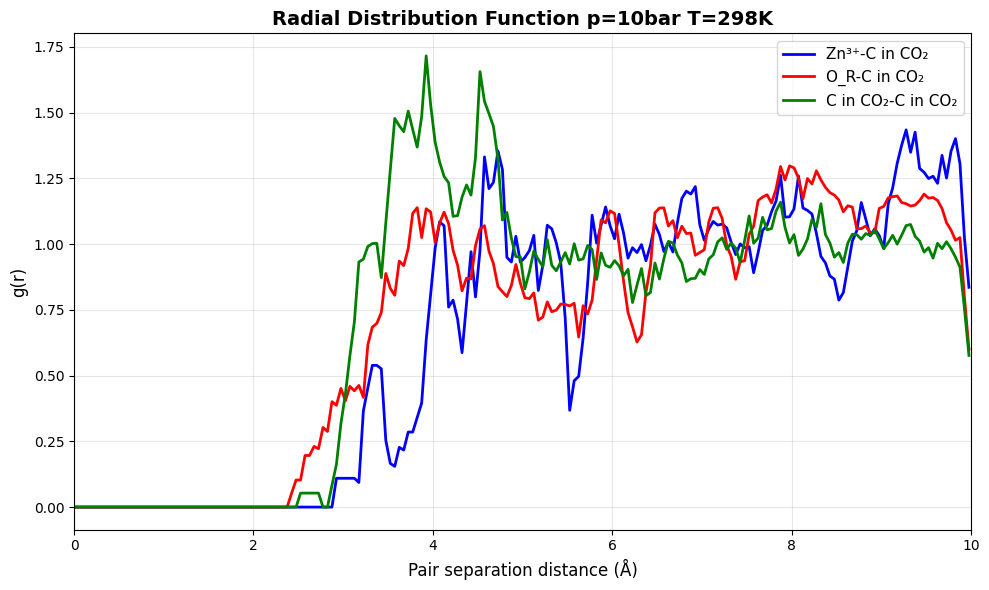

In [57]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d


def plot_rdf(filename: str, smooth: bool = True, method: str = 'savgol') -> None:
    """
    Построение графика радиальной функции распределения для выбранных пар.
    
    Args:
        filename: путь к файлу с данными RDF
        smooth: применять ли сглаживание
        method: метод сглаживания ('savgol', 'spline', 'moving_average')
    """
    # Чтение данных из файла
    data = np.loadtxt(filename, skiprows=2)
    
    # Извлечение колонок
    distance = data[:, 0]  # Расстояние разделения пар
    zn_c_co2 = data[:, 3]  # Zn3+2-C in CO2
    o_c_co2 = data[:, 5]   # O_R-C in CO2  
    c_c_co2 = data[:, 6]   # C in CO2-C in CO2
    

    # Сглаживание данных
    if smooth:
        match method:
            case 'savgol':
                # Фильтр Савицкого-Голея
                window_length = min(21, len(distance) // 4)  # Адаптивная длина окна
                if window_length % 2 == 0:
                    window_length += 1  # Должно быть нечетным
                polyorder = min(3, window_length - 1)
                
                zn_c_co2 = savgol_filter(zn_c_co2, window_length, polyorder)
                o_c_co2 = savgol_filter(o_c_co2, window_length, polyorder)
                c_c_co2 = savgol_filter(c_c_co2, window_length, polyorder)
                
            case 'spline':
                # Сплайн-интерполяция
                distance_new = np.linspace(distance.min(), distance.max(), len(distance) * 2)
                
                f_zn = interp1d(distance, zn_c_co2, kind='cubic')
                f_o = interp1d(distance, o_c_co2, kind='cubic')
                f_c = interp1d(distance, c_c_co2, kind='cubic')
                
                distance = distance_new
                zn_c_co2 = f_zn(distance_new)
                o_c_co2 = f_o(distance_new)
                c_c_co2 = f_c(distance_new)
                
            case 'moving_average':
                # Скользящее среднее
                window = 5
                zn_c_co2 = np.convolve(zn_c_co2, np.ones(window)/window, mode='same')
                o_c_co2 = np.convolve(o_c_co2, np.ones(window)/window, mode='same')
                c_c_co2 = np.convolve(c_c_co2, np.ones(window)/window, mode='same')

    # Создание графика
    plt.figure(figsize=(10, 6))
    
    plt.plot(distance, zn_c_co2, label='Zn³⁺-C in CO₂', linewidth=2, color='blue')
    plt.plot(distance, o_c_co2, label='O_R-C in CO₂', linewidth=2, color='red')
    plt.plot(distance, c_c_co2, label='C in CO₂-C in CO₂', linewidth=2, color='green')
    
    plt.xlabel('Pair separation distance (Å)', fontsize=12)
    plt.ylabel('g(r)', fontsize=12)
    plt.title('Radial Distribution Function p=10bar T=298K', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 10)
    
    # Улучшение внешнего вида
    plt.tight_layout()
    plt.show()


plot_rdf("rdfs/rdf_10p_298K.txt", method = 'moving_average')